## Model Training

#### 1.1 Import Data and Required Packages
##### Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [2]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

#### Import the CSV Data as Pandas DataFrame

In [3]:
df = pd.read_csv('data/stud.csv')

In [4]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### Preparing X and Y variables

In [6]:
X=df.drop(columns=['math_score'])
y=df['math_score']

In [7]:
print("Categories in 'gender' variable:     ",end=" " )
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable:  ",end=" ")
print(df['race_ethnicity'].unique())

print("Categories in'parental level of education' variable:",end=" " )
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable:     ",end=" " )
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable:     ",end=" " )
print(df['test_preparation_course'].unique())

Categories in 'gender' variable:      <StringArray>
['female', 'male']
Length: 2, dtype: str
Categories in 'race_ethnicity' variable:   <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Categories in'parental level of education' variable: <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categories in 'lunch' variable:      <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in 'test preparation course' variable:      <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [8]:
# Create Column Transformer with 3 types of transformers
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder(drop='first')

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
         ("StandardScaler", numeric_transformer, num_features),        
    ]
)

C:\Users\anshb\AppData\Local\Temp\ipykernel_23096\3506310748.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X.select_dtypes(include="object").columns


In [9]:
X = preprocessor.fit_transform(X)

In [10]:
X.shape

(1000, 14)

### separate dataset into train and test

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((800, 14), (200, 14))

#### Create an Evaluate Function to give all metrics after model Training

In [12]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [13]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}

model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 5.3231
- Mean Absolute Error: 4.2667
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.3940
- Mean Absolute Error: 4.2148
- R2 Score: 0.8804


Lasso
Model performance for Training set
- Root Mean Squared Error: 6.5938
- Mean Absolute Error: 5.2063
- R2 Score: 0.8071
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 6.5197
- Mean Absolute Error: 5.1579
- R2 Score: 0.8253


Ridge
Model performance for Training set
- Root Mean Squared Error: 5.3235
- Mean Absolute Error: 4.2650
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.3936
- Mean Absolute Error: 4.2125
- R2 Score: 0.8805


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 5.5678
- Mean Absolute Error: 4.4510
- R2 Score: 0.8625
-----------------------

### Results

In [14]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
2,Ridge,0.880451
0,Linear Regression,0.880433
5,Random Forest Regressor,0.850167
7,CatBoosting Regressor,0.849801
8,AdaBoost Regressor,0.847966
1,Lasso,0.825320
6,XGBRegressor,0.825046
3,K-Neighbors Regressor,0.776335
4,Decision Tree,0.743464


## Ridge Regression

In [15]:
lin_model = Ridge(fit_intercept=True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 88.05


## Plot y_pred and y_test

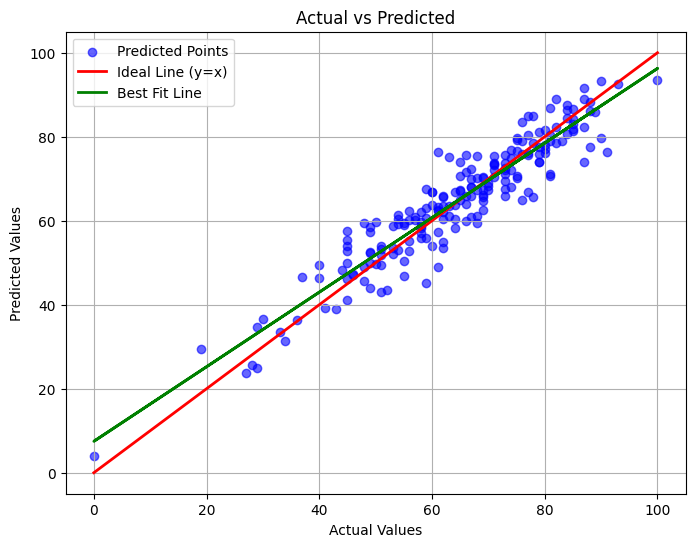

In [16]:
# Scatter plot of actual vs predicted
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, label='Predicted Points')

min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color='red',
    linewidth=2,
    label='Ideal Line (y=x)'
)

# Best fit line
m, b = np.polyfit(y_test, y_pred, 1)
plt.plot(
    y_test,
    m*y_test + b,
    color='green',
    linewidth=2,
    label='Best Fit Line'
)

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted')
plt.legend()
plt.grid(True)

plt.show()

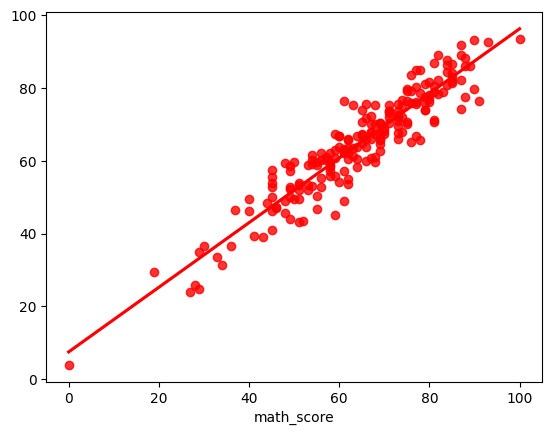

In [17]:
sns.regplot(x=y_test,y=y_pred,ci=None,color ='red');

#### Difference between Actual and Predicted Values

In [18]:
final = {'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred}

In [19]:
pd.DataFrame(final)

,Actual Value,Predicted Value,Difference
521,91,76.405205,14.594795
737,53,58.858134,-5.858134
740,80,76.963473,3.036527
660,74,76.776989,-2.776989
411,84,87.595617,-3.595617
...,...,...,...
408,52,43.528947,8.471053
332,62,62.163717,-0.163717
208,74,67.919929,6.080071
613,65,67.073265,-2.073265


In [20]:
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

In [21]:
sgd_model = SGDRegressor(
    max_iter=1,
    learning_rate='constant',
    eta0=0.001,
    penalty='l2',   # L2 penalty = Ridge Regression
    warm_start=True,
    random_state=42
)

In [23]:
losses = []

for epoch in range(200):
    sgd_model.fit(X_train, y_train)

    y_pred_train = sgd_model.predict(X_train)

    loss = mean_squared_error(y_train, y_pred_train)
    losses.append(loss)

d:\ML projects\STUDENT PERFORMANCE INDICATOR\project1\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
d:\ML projects\STUDENT PERFORMANCE INDICATOR\project1\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
d:\ML projects\STUDENT PERFORMANCE INDICATOR\project1\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
d:\ML projects\STUDENT PERFORMANCE INDICATOR\project1\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consid

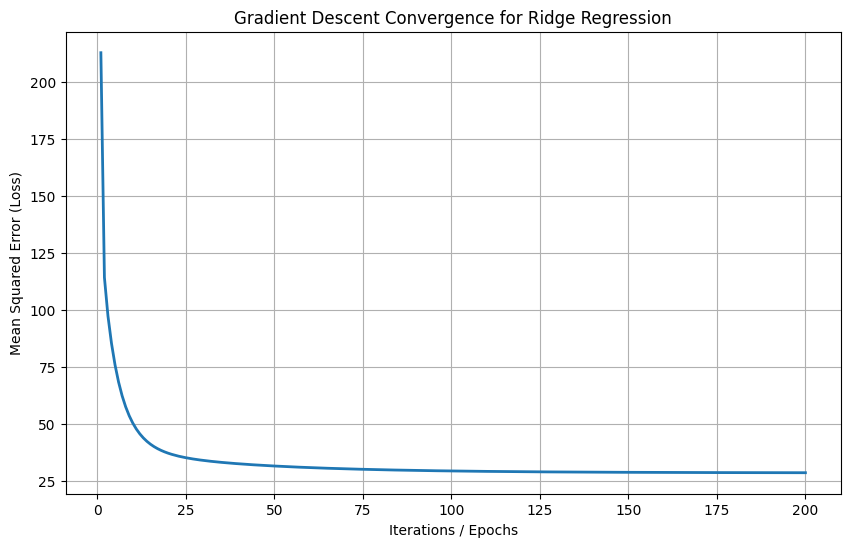

In [24]:
plt.figure(figsize=(10,6))

plt.plot(range(1, 201), losses, linewidth=2)

plt.xlabel('Iterations / Epochs')
plt.ylabel('Mean Squared Error (Loss)')
plt.title('Gradient Descent Convergence for Ridge Regression')

plt.grid(True)
plt.show()

In [25]:
weights_history = []

sgd_model = SGDRegressor(
    max_iter=1,
    learning_rate='constant',
    eta0=0.001,
    penalty='l2',
    warm_start=True,
    random_state=42
)

for epoch in range(200):
    sgd_model.fit(X_train, y_train)
    weights_history.append(sgd_model.coef_.copy())

d:\ML projects\STUDENT PERFORMANCE INDICATOR\project1\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
d:\ML projects\STUDENT PERFORMANCE INDICATOR\project1\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
d:\ML projects\STUDENT PERFORMANCE INDICATOR\project1\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
d:\ML projects\STUDENT PERFORMANCE INDICATOR\project1\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consid

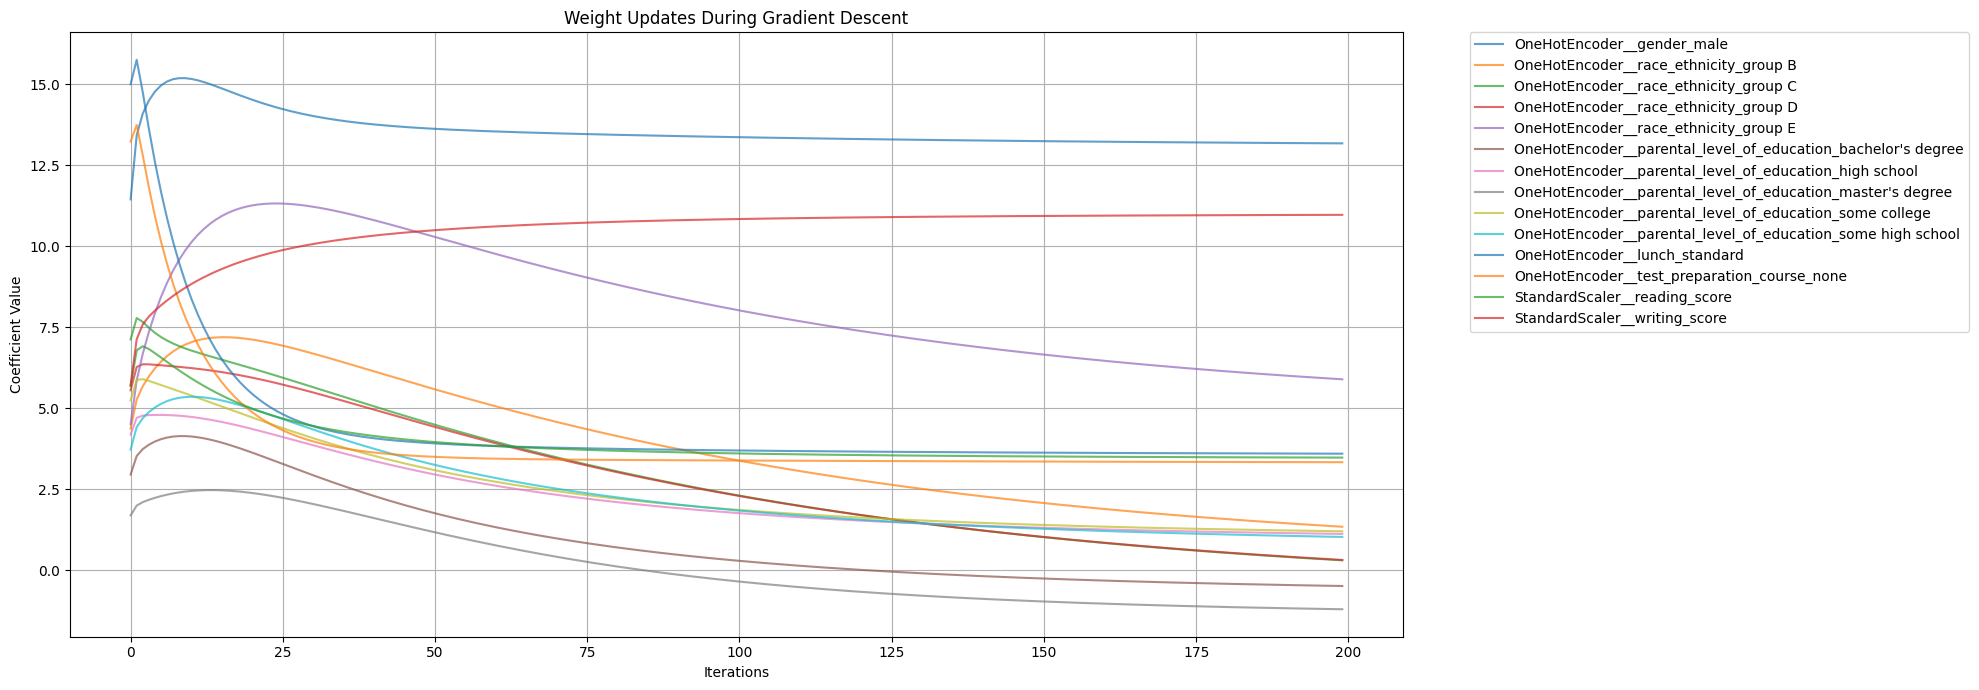

In [34]:
weights_history = np.array(weights_history)

plt.figure(figsize=(20,7))

for i in range(weights_history.shape[1]):
    plt.plot(
        weights_history[:, i],
        alpha=0.7,
        label=feature_names[i]
    )

plt.xlabel('Iterations')
plt.ylabel('Coefficient Value')
plt.title('Weight Updates During Gradient Descent')

# Move legend outside the plot
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.
)

plt.grid(True)

# Prevent overlap
plt.tight_layout()

plt.show()